# Week 1: Transformer Mechanics, Probing GPT-2

**Task:** Probe a pretrained model's tokeniser edge cases and next-token distributions across prompts.

**Reading:** *Attention Is All You Need* (Vaswani et al., 2017)

This notebook uses **GPT-2 small (124M)**. It is a decoder-only transformer (the decoder half of Vaswani et al.) with a byte-level BPE tokeniser. It's small enough to run on a CPU and it's the ancestor of most modern LLMs, so everything here carries over to bigger models.

| Section | Concept |
|---|---|
| 1. Tokeniser edge cases | Tokenisation |
| 2. Embeddings | Token + positional embeddings |
| 3. Next-token distributions | The model's actual output |
| 4. Self-attention | Q·Kᵀ/√d, causal mask, rebuilt by hand |
| 5. Autoregressive generation | Sampling loop, KV cache, temperature/top-k/top-p |

In [1]:
import math, warnings
import torch, numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings("ignore")
torch.manual_seed(0)

MODEL = "gpt2"
tok = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(MODEL, attn_implementation="eager").eval()  # eager -> attention weights available
cfg = model.config
print(f"vocab={cfg.vocab_size:,}  context={cfg.n_positions}  layers={cfg.n_layer}  heads={cfg.n_head}  d_model={cfg.n_embd}")
print(f"params={sum(p.numel() for p in model.parameters())/1e6:.0f}M")

vocab=50,257  context=1024  layers=12  heads=12  d_model=768
params=124M


## 1. Tokeniser edge cases

GPT-2 uses **byte-level BPE**. Text is first turned into UTF-8 bytes, and then frequent byte pairs are merged, again and again, into a vocabulary of 50,257 tokens. Because it starts from bytes, *any* string can be encoded (there's never an unknown token). The catch is that the way a string gets split depends a lot on how often it appeared in the training data.

The helper below prints each token's text. `repr` makes leading spaces visible: `' hello'` and `'hello'` are **different tokens**.

In [2]:
def show(text, ids=False):
    toks = tok.encode(text)
    pieces = [repr(tok.decode([t])) + (f":{t}" if ids else "") for t in toks]
    print(f"{text!r:42} {len(toks):>2} tok | " + " ".join(pieces))
    return toks

cases = {
    "Leading space & case": ["hello", " hello", "Hello", " Hello", "HELLO", " HELLO"],
    "Numbers":              ["7", "42", "2026", "1234567", "3.14159", "123+456=579", "1,000,000"],
    "Whitespace / code":    ["a  b", "a\tb", "a\n\nb", "    return x", "        return x", "if(x==1){y++;}"],
    "Rare & long words":    ["cat", "antidisestablishmentarianism", "Pneumonoultramicroscopic", "ChatGPT", "tokenisation", "tokenization"],
    "Unicode":              ["café", "naïve", "🙂", "👨‍👩‍👧", "你好", "Привет", "مرحبا"],
}
for group, texts in cases.items():
    print(f"\n── {group}")
    for t in texts:
        show(t)


── Leading space & case
'hello'                                     1 tok | 'hello'
' hello'                                    1 tok | ' hello'
'Hello'                                     1 tok | 'Hello'
' Hello'                                    1 tok | ' Hello'
'HELLO'                                     3 tok | 'HE' 'LL' 'O'
' HELLO'                                    2 tok | ' HELL' 'O'

── Numbers
'7'                                         1 tok | '7'
'42'                                        1 tok | '42'
'2026'                                      2 tok | '20' '26'
'1234567'                                   3 tok | '123' '45' '67'
'3.14159'                                   4 tok | '3' '.' '14' '159'
'123+456=579'                               5 tok | '123' '+' '456' '=' '579'
'1,000,000'                                 5 tok | '1' ',' '000' ',' '000'

── Whitespace / code
'a  b'                                      3 tok | 'a' ' ' ' b'
'a\tb'                              

### Byte fallback: tokens don't have to be valid characters

An emoji is 4 or more UTF-8 bytes. If a byte sequence isn't common enough to have been merged into one token, it gets split across several tokens. Each of those tokens holds *part of a character*, so decoding one on its own gives the replacement character `�`. Decoding the whole sequence at once is still lossless.

In [3]:
for s in ["🙂", "👨‍👩‍👧", "你好"]:
    ids = tok.encode(s)
    print(f"{s!r}: utf8 bytes={len(s.encode())}, tokens={len(ids)}")
    print("   raw BPE symbols:", tok.convert_ids_to_tokens(ids))
    print("   decoded 1-by-1 :", [tok.decode([i]) for i in ids])
    print("   decoded jointly:", repr(tok.decode(ids)))

# Round-trip check: byte-level BPE should be lossless for arbitrary strings
weird = ["  leading", "trailing  ", "\t\n\r", "é (combining accent)", "zero​width", "🙂🙃🙂", "混合 mixed текст"]
ok = all(tok.decode(tok.encode(s), clean_up_tokenization_spaces=False) == s for s in weird)
print("\nlossless round-trip on all weird strings:", ok)

'🙂': utf8 bytes=4, tokens=2
   raw BPE symbols: ['ðŁ', 'ĻĤ']
   decoded 1-by-1 : ['�', '��']
   decoded jointly: '🙂'
'👨\u200d👩\u200d👧': utf8 bytes=18, tokens=10
   raw BPE symbols: ['ðŁĳ', '¨', 'âĢ', 'į', 'ðŁĳ', '©', 'âĢ', 'į', 'ðŁĳ', '§']
   decoded 1-by-1 : ['�', '�', '�', '�', '�', '�', '�', '�', '�', '�']
   decoded jointly: '👨\u200d👩\u200d👧'
'你好': utf8 bytes=6, tokens=4
   raw BPE symbols: ['ä½', 'ł', 'å¥', '½']
   decoded 1-by-1 : ['�', '�', '�', '�']
   decoded jointly: '你好'

lossless round-trip on all weird strings: True


### The "token tax": the same meaning costs a different number of tokens in each language

GPT-2's BPE merges were learned mostly from English web text. Here's one sentence in several languages. Token count is what sets both cost and how much text fits in the context window.

lang     chars bytes tokens chars/tok  vs EN
English     71    71     17      4.18   1.0x
French      72    73     30      2.40   1.8x
German      72    74     28      2.57   1.6x
Russian     53    96     57      0.93   3.4x
Chinese     15    45     28      0.54   1.6x
Arabic      49    89     50      0.98   2.9x
Hindi       60   156     91      0.66   5.4x


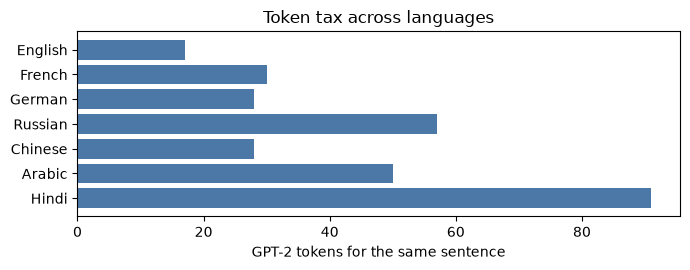

In [4]:
same_sentence = {
    "English": "The weather is beautiful today and I want to go for a walk in the park.",
    "French":  "Il fait très beau aujourd'hui et je veux aller me promener dans le parc.",
    "German":  "Das Wetter ist heute wunderschön und ich möchte im Park spazieren gehen.",
    "Russian": "Сегодня прекрасная погода, и я хочу погулять в парке.",
    "Chinese": "今天天气很好，我想去公园散步。",
    "Arabic":  "الطقس جميل اليوم وأريد أن أذهب للتنزه في الحديقة.",
    "Hindi":   "आज मौसम बहुत सुंदर है और मैं पार्क में टहलने जाना चाहता हूँ।",
}
base = len(tok.encode(same_sentence["English"]))
print(f"{'lang':8} {'chars':>5} {'bytes':>5} {'tokens':>6} {'chars/tok':>9} {'vs EN':>6}")
rows = []
for lang, s in same_sentence.items():
    n = len(tok.encode(s)); rows.append((lang, n))
    print(f"{lang:8} {len(s):5} {len(s.encode()):5} {n:6} {len(s)/n:9.2f} {n/base:5.1f}x")

plt.figure(figsize=(7, 2.8))
plt.barh([r[0] for r in rows][::-1], [r[1] for r in rows][::-1], color="#4C78A8")
plt.xlabel("GPT-2 tokens for the same sentence"); plt.title("Token tax across languages"); plt.tight_layout(); plt.show()

### Special tokens and glitch tokens

* `<|endoftext|>` is the document separator. By default the HF tokeniser turns this literal string into the special token, even when it shows up inside user text. That's a known prompt-injection vector.
* **Glitch tokens** such as `' SolidGoldMagikarp'` got into the vocabulary because they were frequent in the data the *tokeniser* was trained on (Reddit usernames). They were then almost absent from the data the *model* was trained on. The hypothesis is that their embeddings barely moved from initialisation. Section 2 tests this.

In [5]:
show("<|endoftext|>", ids=True)
show("Hello<|endoftext|>world", ids=True)
print("eos token id:", tok.eos_token_id)
print()
GLITCH = [" SolidGoldMagikarp", " TheNitromeFan", " davidjl", " RandomRedditorWithNo"]
for g in GLITCH:
    show(g, ids=True)

'<|endoftext|>'                             1 tok | '<|endoftext|>':50256
'Hello<|endoftext|>world'                   3 tok | 'Hello':15496 '<|endoftext|>':50256 'world':6894
eos token id: 50256

' SolidGoldMagikarp'                        1 tok | ' SolidGoldMagikarp':43453
' TheNitromeFan'                            1 tok | ' TheNitromeFan':42090
' davidjl'                                  1 tok | ' davidjl':23282
' RandomRedditorWithNo'                     1 tok | ' RandomRedditorWithNo':36174


## 2. Embeddings

The first thing the model does is look up a learned vector for each token ID (`wte`, 50257 × 768) and add a learned vector for each position (`wpe`, 1024 × 768). The original paper used fixed sinusoidal position encodings. GPT-2 *learns* them instead.

In [6]:
W = model.transformer.wte.weight.detach()          # token embeddings
P = model.transformer.wpe.weight.detach()          # positional embeddings
print("wte", tuple(W.shape), " wpe", tuple(P.shape))

Wn = W / W.norm(dim=1, keepdim=True)
def neighbours(word, k=8):
    ids = tok.encode(word)
    assert len(ids) == 1, f"{word!r} is {len(ids)} tokens"
    sims = Wn @ Wn[ids[0]]
    top = sims.topk(k + 1).indices[1:]
    print(f"{word!r:12} -> " + ", ".join(repr(tok.decode([i])) for i in top))

for w in [" king", " Paris", "Paris", " dog", " 7", " running", " happy"]:
    neighbours(w)

wte (50257, 768)  wpe (1024, 768)
' king'      -> ' kings', ' King', ' queen', 'King', ' prince', ' monarch', ' emperor', ' ruler'
' Paris'     -> 'Paris', ' France', ' French', ' London', 'France', ' Copenhagen', ' Brussels', 'French'
'Paris'      -> ' Paris', 'France', 'London', 'French', ' France', 'Moscow', ' Copenhagen', 'Manchester'
' dog'       -> ' dogs', ' Dog', 'Dog', ' canine', 'dog', ' Dogs', ' puppy', ' pet'


' 7'         -> ' 6', ' 8', ' 5', ' 9', ' 4', ' 3', ' 10', ' 11'
' running'   -> ' Running', 'Running', 'running', ' ran', ' run', ' runs', ' Run', 'Run'


' happy'     -> 'happy', ' Happy', ' happier', ' unhappy', 'Happy', ' pleased', ' glad', ' thrilled'


Nearest neighbours are mostly **surface-form variants** (case, spacing, plural) plus semantically related words. Note that `' Paris'` and `'Paris'` have separate embeddings that the model had to learn independently.

**Hypothesis: under-trained tokens sit near the embedding centroid.** A token that was almost never seen in training keeps an embedding close to where initialisation and weight decay left it.

In [7]:
dist = (W - W.mean(0)).norm(dim=1)
rank = dist.argsort()                                   # rank 0 = closest to centroid
pos = torch.empty_like(rank); pos[rank] = torch.arange(len(rank))
print("Closest-to-centroid tokens:", [tok.decode([i]) for i in rank[:15]])
print()
for g in GLITCH + [" the", " Paris", " dog"]:
    i = tok.encode(g)[0]
    print(f"{g!r:25} dist={dist[i]:.2f}  rank {pos[i]:>5} / {len(W)}  (percentile {100*pos[i]/len(W):.1f}%)")

Closest-to-centroid tokens: [' externalToEVA', '�', '�', '\x1c', '\x07', '�', 'quickShip', '\x19', '\x0b', '�', '�', '\x16', '\x14', ' TheNitrome', '\x17']

' SolidGoldMagikarp'      dist=3.18  rank 14356 / 50257  (percentile 28.6%)
' TheNitromeFan'          dist=3.29  rank 20963 / 50257  (percentile 41.7%)
' davidjl'                dist=3.37  rank 25072 / 50257  (percentile 49.9%)
' RandomRedditorWithNo'   dist=2.98  rank  6301 / 50257  (percentile 12.5%)
' the'                    dist=3.14  rank 12684 / 50257  (percentile 25.2%)
' Paris'                  dist=3.04  rank  8401 / 50257  (percentile 16.7%)
' dog'                    dist=2.98  rank  6041 / 50257  (percentile 12.0%)


**Result: mixed.** The famous glitch tokens are *not* unusual in GPT-2 (they sit between the 12th and 50th percentile; the centroid result was first reported for GPT-J). But the tokens that *are* closest to the centroid are all under-trained junk: raw control bytes, partial UTF-8 bytes, and other known glitch tokens (`' externalToEVA'`, `'quickShip'`, `' TheNitrome'`). Distance to the centroid is a useful detector of under-trained tokens, but it isn't complete.

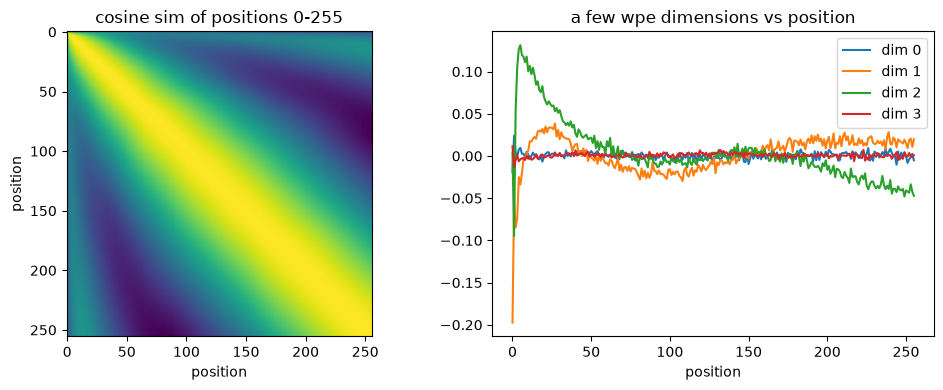

In [8]:
Pn = P / P.norm(dim=1, keepdim=True)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow((Pn[:256] @ Pn[:256].T).numpy(), cmap="viridis"); ax[0].set_title("cosine sim of positions 0-255")
ax[0].set_xlabel("position"); ax[0].set_ylabel("position")
for d in [0, 1, 2, 3]:
    ax[1].plot(P[:256, d].numpy(), label=f"dim {d}")
ax[1].set_title("a few wpe dimensions vs position"); ax[1].legend(); ax[1].set_xlabel("position")
plt.tight_layout(); plt.show()

The learned positional embeddings come out **smooth and wave-like**, with nearby positions being similar. So the model rediscovered roughly the sinusoidal structure that Vaswani et al. built in by hand.

## 3. Next-token distributions

For each position, a causal LM outputs a probability distribution over all 50,257 tokens for what comes *next*. **Entropy** (in bits) measures how spread out that distribution is. 0 bits means the model is certain. log₂(50257) ≈ 15.6 bits would mean it's uniform.

In [9]:
@torch.no_grad()
def next_probs(prompt):
    ids = tok(prompt, return_tensors="pt").input_ids
    return torch.softmax(model(ids).logits[0, -1], dim=-1)

def entropy_bits(p):
    return -(p * torch.log2(p.clamp_min(1e-12))).sum().item()

def top(prompt, k=6, quiet=False):
    p = next_probs(prompt)
    v, i = p.topk(k)
    if not quiet:
        print(f"{prompt!r}   H={entropy_bits(p):.2f} bits")
        print("    " + "  ".join(f"{tok.decode([ix])!r} {pr:.1%}" for pr, ix in zip(v, i)))
    return p

prompts = {
    "fact":        "The capital of France is",
    "fact (hard)": "The chemical symbol for gold is",
    "idiom":       "Actions speak louder than",
    "sequence":    "1, 2, 3, 4, 5,",
    "alphabet":    "A B C D E F",
    "code":        "for i in range(",
    "code (def)":  "def add(a, b):\n    return",
    "arithmetic":  "17 + 25 =",
    "open-ended":  "Yesterday I went to the",
    "story":       "Once upon a",
    "dialogue":    "Q: How are you today?\nA:",
}
stats = {}
for name, pr in prompts.items():
    p = top(pr)
    stats[name] = (entropy_bits(p), p.max().item())

'The capital of France is'   H=8.65 bits
    ' the' 8.5%  ' now' 4.8%  ' a' 4.6%  ' France' 3.2%  ' Paris' 3.2%  ' in' 2.7%
'The chemical symbol for gold is'   H=8.07 bits
    ' the' 22.0%  ' a' 8.2%  ' "' 4.2%  " '" 2.2%  ' an' 1.7%  ' gold' 1.0%
'Actions speak louder than'   H=0.87 bits
    ' words' 93.0%  ' they' 0.8%  ' action' 0.7%  ' their' 0.3%  ' word' 0.3%  ' the' 0.3%


'1, 2, 3, 4, 5,'   H=0.98 bits
    ' 6' 91.0%  ' 7' 1.6%  ' and' 1.2%  ' 5' 1.1%  ' 8' 0.5%  ' 4' 0.4%
'A B C D E F'   H=0.23 bits
    ' G' 98.1%  ' 1' 0.6%  ' g' 0.3%  ' H' 0.1%  'g' 0.1%  'G' 0.0%
'for i in range('   H=7.26 bits
    '0' 16.1%  '1' 12.0%  'i' 8.5%  '10' 3.8%  '100' 2.6%  'len' 2.3%


'def add(a, b):\n    return'   H=7.26 bits
    ' a' 23.2%  ' b' 5.9%  ' (' 5.3%  ' 0' 3.3%  ' 1' 1.9%  '\n' 1.7%
'17 + 25 ='   H=8.52 bits
    ' 0' 4.6%  ' 1' 3.2%  ' 25' 2.6%  ' 10' 2.1%  ' 2' 2.0%  ' 30' 1.9%
'Yesterday I went to the'   H=11.15 bits
    ' store' 2.3%  ' hospital' 2.2%  ' office' 2.2%  ' doctor' 1.8%  ' gym' 1.4%  ' local' 1.3%


'Once upon a'   H=8.51 bits
    ' time' 17.7%  ' certain' 8.5%  ' moment' 3.1%  ' visit' 2.9%  ' while' 1.6%  ' short' 1.4%
'Q: How are you today?\nA:'   H=5.49 bits
    ' I' 33.9%  ' Well' 14.9%  ' It' 3.6%  ' We' 3.3%  ' My' 2.9%  ' Oh' 2.1%


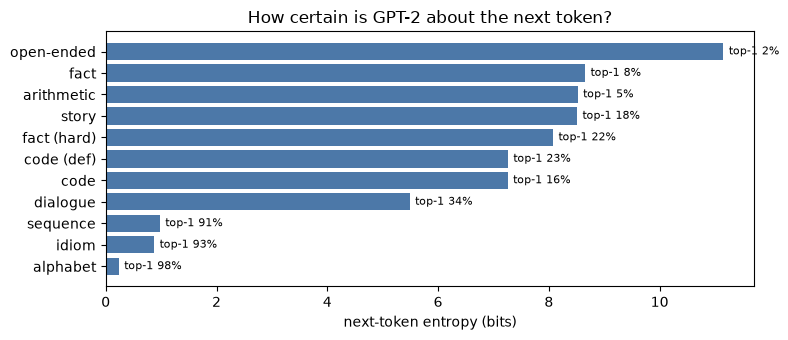

In [10]:
names = sorted(stats, key=lambda n: stats[n][0])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(names, [stats[n][0] for n in names], color="#4C78A8")
ax.set_xlabel("next-token entropy (bits)"); ax.set_title("How certain is GPT-2 about the next token?")
for i, n in enumerate(names):
    ax.text(stats[n][0] + 0.1, i, f"top-1 {stats[n][1]:.0%}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

### Scoring whole continuations

Many answers are several tokens long. To get the probability of a continuation we add up the log-probs of its tokens using the chain rule, P(a,b|x) = P(a|x)·P(b|x,a). This is the same approach used to score multiple-choice questions in LLM evals.

In [11]:
@torch.no_grad()
def logprob(prompt, continuation):
    p_ids = tok.encode(prompt); c_ids = tok.encode(continuation)
    ids = torch.tensor([p_ids + c_ids])
    logp = torch.log_softmax(model(ids).logits[0], dim=-1)
    # logits at position t predict token t+1
    return sum(logp[len(p_ids) + j - 1, c].item() for j, c in enumerate(c_ids))

def rank_options(prompt, options):
    scores = {o: logprob(prompt, o) for o in options}
    z = math.log(sum(math.exp(s) for s in scores.values()))
    print(prompt.replace("\n", "\\n"))
    for o, s in sorted(scores.items(), key=lambda kv: -kv[1]):
        print(f"   {o!r:14} logp={s:7.2f}  ({len(tok.encode(o))} tok)  share among options {math.exp(s - z):6.1%}")

rank_options("The capital of France is", [" Paris", " London", " Berlin", " Lyon"])
rank_options("17 + 25 =", [" 42", " 32", " 52", " 41"])
rank_options("123 + 456 =", [" 579", " 569", " 589", " 1000"])
rank_options("The Eiffel Tower is in", [" Paris", " Rome", " Las Vegas"])

The capital of France is
   ' Paris'       logp=  -3.43  (1 tok)  share among options  87.3%
   ' London'      logp=  -6.16  (1 tok)  share among options   5.7%
   ' Berlin'      logp=  -6.45  (1 tok)  share among options   4.3%
   ' Lyon'        logp=  -6.94  (1 tok)  share among options   2.6%


17 + 25 =
   ' 32'          logp=  -4.79  (1 tok)  share among options  43.6%
   ' 42'          logp=  -5.45  (1 tok)  share among options  22.5%
   ' 52'          logp=  -5.56  (1 tok)  share among options  20.1%
   ' 41'          logp=  -5.93  (1 tok)  share among options  13.8%


123 + 456 =
   ' 1000'        logp=  -7.02  (1 tok)  share among options  70.9%
   ' 569'         logp=  -8.85  (2 tok)  share among options  11.4%
   ' 579'         logp=  -9.04  (2 tok)  share among options   9.4%
   ' 589'         logp=  -9.15  (2 tok)  share among options   8.4%
The Eiffel Tower is in
   ' Paris'       logp=  -4.77  (1 tok)  share among options  80.9%
   ' Rome'        logp=  -6.34  (1 tok)  share among options  16.8%
   ' Las Vegas'   logp=  -8.36  (2 tok)  share among options   2.2%


### Prompt sensitivity: small surface changes, big distribution changes

Almost all of these perturbations come back to **tokenisation**. The classic example is a trailing space. In GPT-2's vocabulary the space is *attached to the next word* (`' Paris'`). A prompt that ends in a space therefore forces the model to predict a token with no leading space, and it rarely saw that pattern in training.

In [12]:
pairs = [
    ("The capital of France is",  " Paris"),
    ("The capital of France is ", "Paris"),     # trailing space
    ("the capital of france is",  " paris"),    # lowercase
    ("the capital of france is",  " Paris"),
    ("THE CAPITAL OF FRANCE IS",  " PARIS"),
    ("Q: What is the capital of France?\nA:", " Paris"),
    ("France's capital city is called", " Paris"),
    ("Paris is the capital of", " France"),     # reversal
]
for prompt, ans in pairs:
    p = next_probs(prompt)
    a = tok.encode(ans)
    first = p[a[0]].item()
    print(f"{prompt!r:45} P({ans!r:9})={first:7.2%}  rank={int((p > p[a[0]]).sum())+1:>4}  H={entropy_bits(p):.2f}  ({len(a)} tok)")

'The capital of France is'                    P(' Paris' )=  3.22%  rank=   5  H=8.65  (1 tok)
'The capital of France is '                   P('Paris'  )=  0.00%  rank=1472  H=2.55  (1 tok)
'the capital of france is'                    P(' paris' )=  0.01%  rank= 953  H=10.03  (2 tok)


'the capital of france is'                    P(' Paris' )=  3.57%  rank=   2  H=10.03  (1 tok)
'THE CAPITAL OF FRANCE IS'                    P(' PARIS' )=  0.05%  rank= 306  H=8.01  (2 tok)
'Q: What is the capital of France?\nA:'       P(' Paris' )=  1.77%  rank=   7  H=6.51  (1 tok)


"France's capital city is called"             P(' Paris' )=  0.67%  rank=  16  H=9.11  (1 tok)
'Paris is the capital of'                     P(' France')=  4.13%  rank=   3  H=7.04  (1 tok)


In [13]:
print("After a trailing space, what does GPT-2 expect?")
top("The capital of France is ", k=8)
print("Tokens of the prompt:", [tok.decode([t]) for t in tok.encode("The capital of France is ")])

After a trailing space, what does GPT-2 expect?
'The capital of France is '   H=2.55 bits
    '\xa0' 39.8%  'ét' 34.2%  'Â' 9.1%  'vern' 6.8%  'iced' 1.2%  'Ã' 0.7%  '�' 0.7%  'ers' 0.5%
Tokens of the prompt: ['The', ' capital', ' of', ' France', ' is', ' ']


### Surprisal of a whole text (perplexity)

The same forward pass gives a next-token distribution at **every** position (the causal mask makes that possible). This is what makes training efficient: one sequence gives T training examples. Surprisal = −log₂ P(token | prefix). Perplexity = 2^(mean surprisal).

natural    perplexity=   162.5
shuffled   perplexity=  7728.1


technical  perplexity=   161.9


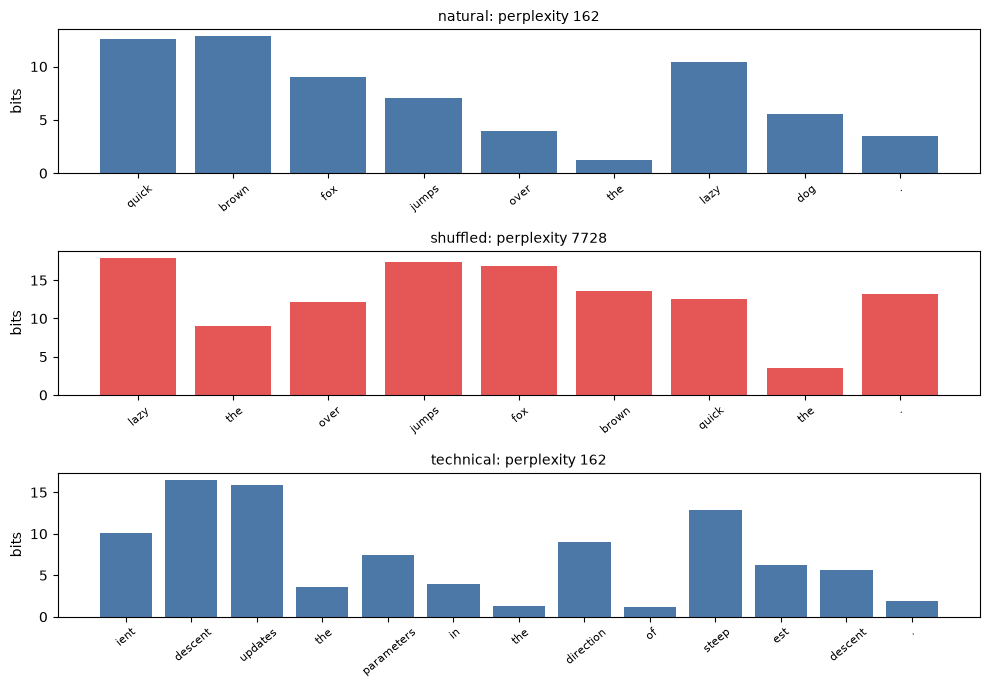

In [14]:
@torch.no_grad()
def surprisal(text):
    ids = tok(text, return_tensors="pt").input_ids
    logp = torch.log_softmax(model(ids).logits[0, :-1], -1)
    s = -logp.gather(1, ids[0, 1:, None]).squeeze(1) / math.log(2)
    return [tok.decode([i]) for i in ids[0, 1:]], s

texts = {
    "natural":   "The quick brown fox jumps over the lazy dog.",
    "shuffled":  "Dog lazy the over jumps fox brown quick the.",
    "technical": "Gradient descent updates the parameters in the direction of steepest descent.",
}
fig, axes = plt.subplots(len(texts), 1, figsize=(10, 7))
for ax, (name, t) in zip(axes, texts.items()):
    toks, s = surprisal(t)
    ppl = 2 ** s.mean().item()
    ax.bar(range(len(s)), s.numpy(), color="#E45756" if name == "shuffled" else "#4C78A8")
    ax.set_xticks(range(len(s))); ax.set_xticklabels(toks, rotation=40, fontsize=8)
    ax.set_ylabel("bits"); ax.set_title(f"{name}: perplexity {ppl:.0f}", fontsize=10)
    print(f"{name:10} perplexity={ppl:8.1f}")
plt.tight_layout(); plt.show()

## 4. Self-attention

For each head: **Attention(Q,K,V) = softmax(QKᵀ/√dₖ + M)·V**. M is the causal mask, which puts −∞ above the diagonal so a token can't look at the future. First we rebuild layer 0's attention **by hand** from the weights and check it against what the model reports.

In [15]:
sent = "The animal didn't cross the street because it was too tired"
enc = tok(sent, return_tensors="pt")
with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = torch.stack(out.attentions)[:, 0]          # (layers, heads, T, T)
toks = [tok.decode([i]) for i in enc.input_ids[0]]
T = len(toks); H = cfg.n_head; dh = cfg.n_embd // H

# --- manual layer-0 attention ---
with torch.no_grad():
    x = model.transformer.wte(enc.input_ids[0]) + model.transformer.wpe(torch.arange(T))  # (T, 768)
    blk = model.transformer.h[0]
    q, k, v = blk.attn.c_attn(blk.ln_1(x)).split(cfg.n_embd, dim=-1)                       # each (T, 768)
    q, k = (t.view(T, H, dh).transpose(0, 1) for t in (q, k))                               # (H, T, 64)
    scores = q @ k.transpose(-1, -2) / math.sqrt(dh)                                        # (H, T, T)
    mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
    A = scores.masked_fill(mask, float("-inf")).softmax(-1)

print("manual attention == model attention:", torch.allclose(A, att[0], atol=1e-5))
print("max weight on future tokens (causal mask):", att[:, :, mask].max().item())

manual attention == model attention: True
max weight on future tokens (causal mask): 0.0


### Which heads link "it" to "animal"?

Coreference is the textbook example of what attention is for. We look for heads where `it` attends more to `animal` than to `street`.

strongest 'it'->'animal' head: layer 4, head 3   (it->animal 0.85, it->street 0.00)


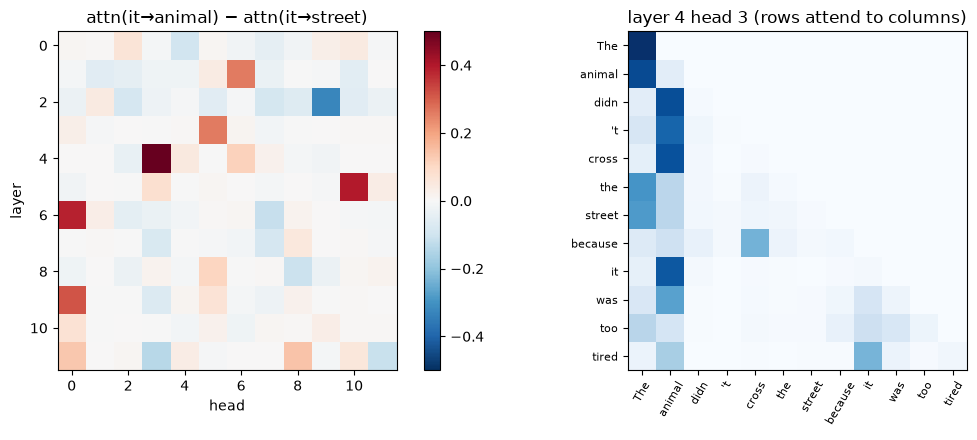

In [16]:
i_it, i_an, i_st = toks.index(" it"), toks.index(" animal"), toks.index(" street")
pref = (att[:, :, i_it, i_an] - att[:, :, i_it, i_st])      # (layers, heads)
L, Hh = divmod(pref.argmax().item(), H)
print(f"strongest 'it'->'animal' head: layer {L}, head {Hh}   "
      f"(it->animal {att[L,Hh,i_it,i_an]:.2f}, it->street {att[L,Hh,i_it,i_st]:.2f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
im = ax[0].imshow(pref.numpy(), cmap="RdBu_r", vmin=-0.5, vmax=0.5)
ax[0].set_xlabel("head"); ax[0].set_ylabel("layer"); ax[0].set_title("attn(it→animal) − attn(it→street)")
plt.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].imshow(att[L, Hh].numpy(), cmap="Blues")
ax[1].set_xticks(range(T)); ax[1].set_xticklabels(toks, rotation=60, fontsize=8)
ax[1].set_yticks(range(T)); ax[1].set_yticklabels(toks, fontsize=8)
ax[1].set_title(f"layer {L} head {Hh} (rows attend to columns)")
plt.tight_layout(); plt.show()

### Attention sinks

Look at how much attention goes to the **first token**. The softmax forces every row to sum to 1, so a head that has "nothing useful to attend to" parks its weight on position 0. This is a well-known phenomenon (Xiao et al., 2023, *StreamingLLM*).

In [17]:
sink = att[:, :, 4:, 0].mean(dim=(1, 2))          # avg attention to token 0, from queries at pos>=4
uniform = torch.tensor([1 / (q + 1) for q in range(4, T)]).mean()
for l, s in enumerate(sink):
    print(f"layer {l:2d}: {s:5.1%} of attention on token 0 " + "█" * int(s * 40))
print(f"(if attention were uniform over the prefix: {uniform:.1%})")

layer  0: 19.3% of attention on token 0 ███████
layer  1: 37.8% of attention on token 0 ███████████████
layer  2: 35.7% of attention on token 0 ██████████████
layer  3: 49.2% of attention on token 0 ███████████████████
layer  4: 53.7% of attention on token 0 █████████████████████
layer  5: 70.2% of attention on token 0 ████████████████████████████
layer  6: 67.0% of attention on token 0 ██████████████████████████
layer  7: 77.3% of attention on token 0 ██████████████████████████████
layer  8: 72.6% of attention on token 0 █████████████████████████████
layer  9: 78.0% of attention on token 0 ███████████████████████████████
layer 10: 81.5% of attention on token 0 ████████████████████████████████
layer 11: 68.0% of attention on token 0 ███████████████████████████
(if attention were uniform over the prefix: 12.7%)


## 5. Autoregressive generation

Generation is just **the next-token distribution in a loop**: sample a token, append it, repeat. The **KV cache** means each step only processes the one new token, because keys and values for the earlier tokens are reused from the previous steps.

In [18]:
@torch.no_grad()
def generate(prompt, n=40, temperature=1.0, top_k=None, top_p=None, greedy=False, seed=0):
    g = torch.Generator().manual_seed(seed)
    ids = tok.encode(prompt)
    x, past = torch.tensor([ids]), None
    for _ in range(n):
        out = model(x, past_key_values=past, use_cache=True)
        past, logits = out.past_key_values, out.logits[0, -1]
        if greedy:
            nxt = logits.argmax().item()
        else:
            logits = logits / temperature
            if top_k:
                logits[logits < logits.topk(top_k).values[-1]] = float("-inf")
            if top_p:
                sl, si = logits.sort(descending=True)
                cum = sl.softmax(-1).cumsum(-1)
                drop = cum - sl.softmax(-1) > top_p            # keep smallest set with mass >= top_p
                logits[si[drop]] = float("-inf")
            nxt = torch.multinomial(logits.softmax(-1), 1, generator=g).item()
        ids.append(nxt)
        x = torch.tensor([[nxt]])                             # only the new token goes in: KV cache has the rest
        if nxt == tok.eos_token_id:
            break
    return tok.decode(ids)

prompt = "In a shocking finding, scientists discovered"
mine = generate(prompt, n=30, greedy=True)
ref = tok.decode(model.generate(**tok(prompt, return_tensors="pt"), max_new_tokens=30, do_sample=False,
                                pad_token_id=tok.eos_token_id)[0])
print("manual greedy == HF generate:", mine == ref)
print(mine)

manual greedy == HF generate: True
In a shocking finding, scientists discovered that the brain of a man who had been diagnosed with schizophrenia had a higher level of dopamine than that of a woman who had not.

The


### Decoding strategies

* **Greedy** always picks the argmax. It's deterministic, but small models tend to fall into repetition loops with it.
* **Temperature** divides the logits by T before the softmax. T→0 approaches greedy. T>1 flattens the distribution toward noise.
* **Top-k / top-p (nucleus)** cut off the long tail of unlikely tokens and then sample from what's left.

In [19]:
prompt = "The best thing about living in a big city is"
settings = [
    ("greedy",           dict(greedy=True)),
    ("T=0.3",            dict(temperature=0.3)),
    ("T=0.7, top_p=0.9", dict(temperature=0.7, top_p=0.9)),
    ("T=1.0",            dict(temperature=1.0)),
    ("T=1.0, top_k=40",  dict(temperature=1.0, top_k=40)),
    ("T=1.8",            dict(temperature=1.8)),
]
for name, kw in settings:
    text = generate(prompt, n=45, seed=1, **kw)[len(prompt):]
    print(f"── {name}\n{prompt}\033[1m{text}\033[0m\n")

── greedy
The best thing about living in a big city is that you can get to know people and get to know them better.

"I've been to a lot of places where I've been to a lot of places where I've been to a lot of places where I



── T=0.3
The best thing about living in a big city is that you can get to know the people you love. You can get to know the people you don't know. You can get to know the people you like. You can get to know the people you don't like.



── T=0.7, top_p=0.9
The best thing about living in a big city is that you're not going to be afraid to walk down the street and see people who are different than you," he said. "People that have a different perspective on life are going to come out and be more understanding of it



── T=1.0
The best thing about living in a big city is when you're feeling open and relaxed. Have yourself a take-out buffet from which to enjoy your sunny morning.


3. It's best if you're not going to do that amazing work when you wake up.



── T=1.0, top_k=40
The best thing about living in a big city is when you're feeling secure," he said.

And that's where people need to be prepared for what's coming up during this year's legislative session.

The House will convene April 2 in Charlotte's Jefferson



── T=1.8
The best thing about living in a big city is yourself! —​ opensburghExuckedzeePat Resource Story

79 enjoying greater accountability De publicly bets gain AVGlassDem pred PanzerBut 95Ironically fatal Dealabg Essentially rent Ha ha weighted guidelines embellish92ature rolls



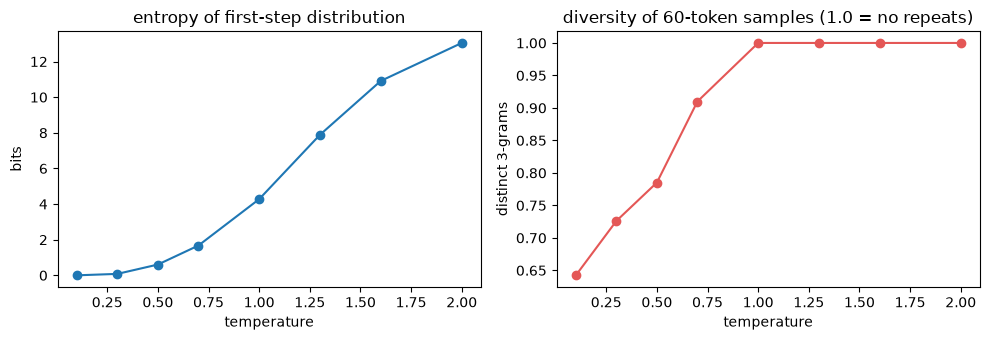

In [20]:
def distinct_ngrams(text, n=3):
    w = text.split()
    grams = [tuple(w[i:i+n]) for i in range(len(w) - n + 1)]
    return len(set(grams)) / max(1, len(grams))

temps = [0.1, 0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0]
logits = torch.log(next_probs(prompt))
ent = [entropy_bits(torch.softmax(logits / t, -1)) for t in temps]
div = [np.mean([distinct_ngrams(generate(prompt, n=60, temperature=t, seed=s)[len(prompt):]) for s in range(3)])
       for t in temps]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(temps, ent, "o-"); ax[0].set_xlabel("temperature"); ax[0].set_ylabel("bits")
ax[0].set_title("entropy of first-step distribution")
ax[1].plot(temps, div, "o-", color="#E45756"); ax[1].set_xlabel("temperature"); ax[1].set_ylabel("distinct 3-grams")
ax[1].set_title("diversity of 60-token samples (1.0 = no repeats)")
plt.tight_layout(); plt.show()

## Findings

**Tokenisation**
1. **Spaces belong to the next word.** `' hello'` and `'hello'` are different tokens with separately learned embeddings. Case matters too: `'HELLO'` → `HE|LL|O`.
2. **Numbers are split inconsistently.** `2026` → `20|26`, `1234567` → `123|45|67`, `3.14159` → `3|.|14|159`. Digit groups don't line up with place value, which is one reason small LMs are poor at arithmetic.
3. **Whitespace is expensive.** Each indentation space is its own token (8-space indent = 8 tokens), so code costs a lot. (Later tokenisers such as cl100k added whitespace-run tokens.)
4. **Byte fallback makes the tokeniser lossless but produces tokens that aren't characters.** 🙂 = 2 tokens that each decode to `�`, and a 3-person family emoji = 10 tokens. Every weird string still round-trips exactly.
5. **Token tax.** The same sentence costs 1.6× (Chinese, German), 1.8× (French), 2.9× (Arabic), 3.4× (Russian) and **5.4× (Hindi)** as many tokens as English. That means proportionally higher cost and less usable context.
6. **Special-token injection.** The literal string `<|endoftext|>` in user text becomes the real EOS token (id 50256).

**Next-token distributions**
7. Entropy varies from **0.23 bits** (`A B C D E F` → `G` 98%) to **11 bits** (`Yesterday I went to the`). Memorised patterns (idioms, sequences) are near-deterministic.
8. **GPT-2 small knows facts only weakly.** `The capital of France is` → `' Paris'` gets only 3.2% (rank 5, behind `' the'`/`' now'`/`' a'`). Among a fixed set of options it still wins with 87%, so the knowledge is there but hidden under generic continuations. This is why evals score options instead of relying on free generation.
9. **Arithmetic fails.** `17 + 25 =` prefers `32` over `42`, and `123 + 456 =` prefers `1000`.
10. **One trailing space breaks the prompt.** P(Paris) drops from 3.2% to **~0%** (rank 1472). The model then predicts `'\xa0'` and `'ét'` because a standalone space token is out of distribution. Lowercasing the prompt barely matters, but an ALL-CAPS answer (`' PARIS'`, 2 tokens) drops to rank 306.
11. Perplexity: natural sentence ≈ 160, the same words shuffled ≈ 7700 (about 48× more surprised).

**Attention and generation**
12. Rebuilt layer-0 attention by hand (`softmax(QKᵀ/√d + causal mask)`) and it **matches the model exactly**. Weight on future tokens is exactly 0.
13. **Layer 4, head 3** links `it` → `animal` with weight 0.85 (vs 0.00 → `street`), That looks like coreference. **Caveat:** the heatmap shows this head sends *almost every* token to `animal`, so it's more of a 'main subject noun' head than a dedicated coreference head. An attention pattern suggests a mechanism but doesn't prove one.
14. **Attention sinks.** Deeper layers put 50–80% of attention on token 0, against a uniform baseline of about 13%.
15. The hand-written KV-cached greedy loop reproduces `model.generate` exactly. Greedy decoding falls into a repetition loop within about 30 tokens. T≈0.7 + top-p 0.9 gives the most coherent text, and T=1.8 gives word salad.